In [1]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.set_backend('numpy')
tl.get_backend()

'numpy'

In [2]:
from moabb.paradigms import P300,LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery()
dataset = BNCI2014_004()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


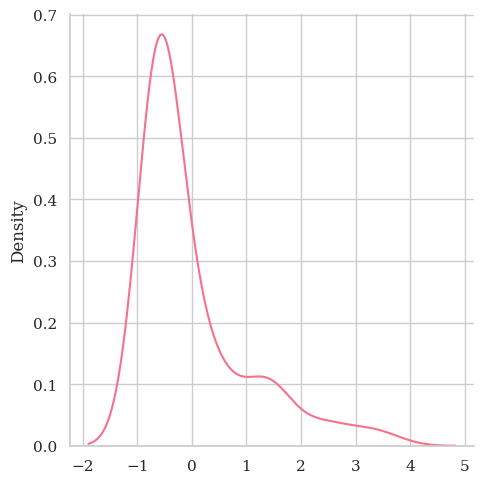

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor

X = epochs.get_data()
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
X = tl.tensor(X)
y = labels
import seaborn as sns
sns.displot(X[:,2,3,0], kind="kde")

In [8]:
tl.min(X)

-1.3322430184986822

In [12]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[1]*4,
    hoda_params=dict(
        max_iter=1024,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X,y)

Fitting block 1/4...


Forward model :   1%|          | 9/1024 [00:00<00:31, 32.18it/s]


Fitting block 2/4...


Forward model :   6%|▌         | 57/1024 [00:01<00:25, 38.14it/s]


Fitting block 3/4...


Forward model :   3%|▎         | 28/1024 [00:00<00:27, 35.69it/s]


Fitting block 4/4...


Forward model :   2%|▏         | 25/1024 [00:00<00:26, 37.33it/s]


CPU times: user 32.6 s, sys: 2.31 s, total: 34.9 s
Wall time: 9.55 s


BTTDA(extra_train_info=True,
      hoda_params={'extra_train_info': False, 'forward': False,
                   'init': 'random', 'max_iter': 1024, 'obj': 'rt',
                   'random_state': 42, 'rank': 1, 'shrinkage': 'lw',
                   'solver': 'lanczos', 'taper': True, 'toeplitz': None,
                   'tol': 1e-08, 'verbose': True},
      ranks=[1, 1, 1, 1], verbose=True)

In [13]:
bttda.train_info_

{'block': [1, 2, 3, 4],
 'rank': [(1, 1, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1)],
 'F_tr': [0.02576159465771335,
  0.02320265828014921,
  0.018840861656668338,
  0.017936797826492473],
 'F_rt': [0.05066446949350292,
  0.07116962699739399,
  0.09034194939324137,
  0.11085476316157573],
 'mse': [0.9850852555396965,
  0.9839109291535769,
  0.9814649235336931,
  0.9793783127195715],
 'nmse': [0.9850852555396965,
  0.9839109291535769,
  0.9814649235336931,
  0.9793783127195715]}

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='block', ylabel='nmse'>

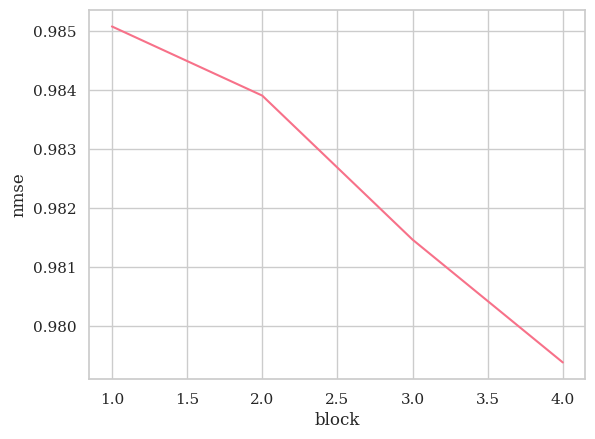

In [14]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
sns.lineplot(data=df, x='block', y='nmse')